In [1]:
import feedparser
import requests
import re
url = "https://www.cert.ssi.gouv.fr/feed/"
rss_feed = feedparser.parse(url)
for entry in rss_feed.entries:
    print("Titre :", entry.title)
    print("Description:", entry.description)
    print("Lien :", entry.link)
    print("Date :", entry.published)

Titre : [Màj] Vulnérabilité dans Microsoft Exchange Server (15 mai 2026)
Description: [Mise à jour du 11 juin 2026] Le 9 juin 2026, Microsoft a publié des versions correctives. [Publication initiale] Le 14 mai 2026, Microsoft a publié un avis de sécurité concernant la vulnérabilité CVE-2026-42897 affectant Exchange Server. Elle permet à un attaquant non authentifié de provoquer...
Lien : https://www.cert.ssi.gouv.fr/alerte/CERTFR-2026-ALE-005/
Date : Fri, 15 May 2026 00:00:00 +0000
Titre : Vulnérabilité dans Cisco Catalyst SD-WAN (05 juin 2026)
Description: Une vulnérabilité a été découverte dans Cisco Catalyst SD-WAN. Elle permet à un attaquant de provoquer une élévation de privilèges. Cisco indique que la vulnérabilité CVE-2026-20245 est activement exploitée.
Lien : https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-AVI-0699/
Date : Fri, 05 Jun 2026 00:00:00 +0000
Titre : Multiples vulnérabilités dans les produits SAP (09 juin 2026)
Description: De multiples vulnérabilités ont été découve

In [2]:
urls_json = []
res=[]
for entry in rss_feed.entries:
    urls_json.append(entry.link+"json/")
for url in urls_json:
    response = requests.get(url)

    if response.status_code == 404:
        print(f"Pas de JSON pour : {url}")
        continue

    if response.status_code != 200:
        print(f"Erreur {response.status_code} pour : {url}")
        continue

    if not response.text.strip():
        print(f"Réponse vide pour : {url}")
        continue

    try:
        data = response.json()
    except Exception as e:
        print(f"JSON invalide pour {url} : {e}")
        continue

    response = requests.get(url)
    data = response.json()
    #Extraction des CVE reference dans la clé cves du dict data
    ref_cves = data.get("cves", [])
    #attention il s’agit d’une liste des dictionnaires avec name et url comme clés
    print( "CVE référencés ", ref_cves)
    # Extraction des CVE avec une regex
    cve_pattern = r"CVE-\d{4}-\d{4,7}"
    cve_list = set(re.findall(cve_pattern, str(data)))
    for cve in cve_list:
         print(f"  - {cve}")
    res.append(cve_list)
print(res)


CVE référencés  [{'name': 'CVE-2026-42897', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-42897'}]
  - CVE-2026-42897
CVE référencés  [{'name': 'CVE-2026-20245', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-20245'}]
  - CVE-2026-20245
CVE référencés  [{'name': 'CVE-2026-44746', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-44746'}, {'name': 'CVE-2026-44750', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-44750'}, {'name': 'CVE-2026-44743', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-44743'}, {'name': 'CVE-2026-44755', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-44755'}, {'name': 'CVE-2026-44754', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-44754'}, {'name': 'CVE-2026-29145', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-29145'}, {'name': 'CVE-2026-44751', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-44751'}, {'name': 'CVE-2026-44757', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-44757'}, {'name': 'CVE-2026-27671', 'url': 'https://www.cve.

In [3]:
import time

def get_cvss_cwe(cve_id):
    try:
        url = f"https://cveawg.mitre.org/api/cve/{cve_id}"
        response = requests.get(url, timeout=10)
        if response.status_code != 200:
            return None, None, None
        data = response.json()
        cna = data["containers"]["cna"]

        try:
            description = cna["descriptions"][0]["value"]
        except:
            description = "Non disponible"

        cvss_score = None
        try:
            metrics = cna.get("metrics", [{}])[0]
            for key in ["cvssV3_1", "cvssV3_0", "cvssV2_0"]:
                if key in metrics:
                    cvss_score = metrics[key]["baseScore"]
                    break
        except:
            pass

        cwe = "Non disponible"
        try:
            problemtype = cna.get("problemTypes", [])
            if problemtype and "descriptions" in problemtype[0]:
                cwe = problemtype[0]["descriptions"][0].get("cweId", "Non disponible")
        except:
            pass

        return description, cvss_score, cwe

    except Exception as e:
        print(f"Erreur MITRE pour {cve_id} : {e}")
        return None, None, None


def get_epss(cve_id):
    try:
        url = f"https://api.first.org/data/v1/epss?cve={cve_id}"
        response = requests.get(url, timeout=10)
        data = response.json()
        epss_data = data.get("data", [])
        if epss_data:
            return float(epss_data[0]["epss"])
        return None
    except Exception as e:
        print(f"Erreur EPSS pour {cve_id} : {e}")
        return None


all_cves = set()
for cve_set in res:
    all_cves.update(cve_set)

print(f"Total CVE uniques à enrichir : {len(all_cves)}")

cve_enriched = {}

for cve_id in all_cves:
    print(f"Enrichissement de {cve_id}...")
    description, cvss_score, cwe = get_cvss_cwe(cve_id)
    epss_score = get_epss(cve_id)
    cve_enriched[cve_id] = {
        "description": description,
        "cvss_score": cvss_score,
        "cwe": cwe,
        "epss_score": epss_score
    }
    time.sleep(0.2)

print("Enrichissement terminé.")

Total CVE uniques à enrichir : 1237
Enrichissement de CVE-2026-8571...
Enrichissement de CVE-2026-23151...
Enrichissement de CVE-2026-46011...
Enrichissement de CVE-2026-11131...
Enrichissement de CVE-2026-45604...
Enrichissement de CVE-2026-45839...
Enrichissement de CVE-2026-10011...
Enrichissement de CVE-2026-46058...
Enrichissement de CVE-2026-43958...
Enrichissement de CVE-2025-58181...
Enrichissement de CVE-2026-43013...
Enrichissement de CVE-2026-41003...
Enrichissement de CVE-2026-10004...
Enrichissement de CVE-2026-46196...
Enrichissement de CVE-2026-47292...
Enrichissement de CVE-2026-46109...
Enrichissement de CVE-2026-9110...
Enrichissement de CVE-2026-23146...
Enrichissement de CVE-2026-8566...
Enrichissement de CVE-2026-45643...
Enrichissement de CVE-2026-23093...
Enrichissement de CVE-2026-8509...
Enrichissement de CVE-2026-45597...
Enrichissement de CVE-2026-9752...
Enrichissement de CVE-2026-8546...
Enrichissement de CVE-2026-23011...
Enrichissement de CVE-2026-46075..

In [6]:
import pandas as pd

rows = []

for entry in rss_feed.entries:
    url_json = entry.link + "json/"
    
    try:
        response = requests.get(url_json, timeout=10)
        if response.status_code != 200:
            continue
        data = response.json()
    except:
        continue

    bulletin_id = data.get("id", "Non disponible")
    titre = entry.title.replace("\n", " ").replace("\r", " ")
    date_pub = entry.published
    lien = entry.link
    type_bulletin = "Alerte" if "alerte" in lien.lower() or "ale" in bulletin_id.lower() else "Avis"

    cve_pattern = r"CVE-\d{4}-\d{4,7}"
    cve_list = list(set(re.findall(cve_pattern, str(data))))

    if not cve_list:
        rows.append({
            "ID ANSSI": bulletin_id,
            "Titre": titre,
            "Type": type_bulletin,
            "Date": date_pub,
            "CVE": None,
            "CVSS Score": None,
            "CWE": None,
            "EPSS Score": None,
            "Description": None,
            "Lien": lien
        })
        continue

    for cve_id in cve_list:
        enriched = cve_enriched.get(cve_id, {})
        description = enriched.get("description")
        if description:
            description = description.replace("\n", " ").replace("\r", " ").replace(";", ",")
        rows.append({
            "ID ANSSI": bulletin_id,
            "Titre": titre,
            "Type": type_bulletin,
            "Date": date_pub,
            "CVE": cve_id,
            "CVSS Score": enriched.get("cvss_score"),
            "CWE": enriched.get("cwe"),
            "EPSS Score": enriched.get("epss_score"),
            "Description": description,
            "Lien": lien
        })

df = pd.DataFrame(rows)
print(df.head())
print(df.shape)

df.to_csv("anssi_cve_consolidated.csv", index=False, sep=";")
print("Fichier CSV exporté.")

         ID ANSSI                                              Titre    Type  \
0  Non disponible  [Màj] Vulnérabilité dans Microsoft Exchange Se...  Alerte   
1  Non disponible  Vulnérabilité dans Cisco Catalyst SD-WAN (05 j...    Avis   
2  Non disponible  Multiples vulnérabilités dans les produits SAP...    Avis   
3  Non disponible  Multiples vulnérabilités dans les produits SAP...    Avis   
4  Non disponible  Multiples vulnérabilités dans les produits SAP...    Avis   

                              Date             CVE  CVSS Score      CWE  \
0  Fri, 15 May 2026 00:00:00 +0000  CVE-2026-42897         8.1   CWE-79   
1  Fri, 05 Jun 2026 00:00:00 +0000  CVE-2026-20245         7.8  CWE-116   
2  Tue, 09 Jun 2026 00:00:00 +0000  CVE-2026-44755         4.3  CWE-346   
3  Tue, 09 Jun 2026 00:00:00 +0000  CVE-2026-44751         7.1  CWE-862   
4  Tue, 09 Jun 2026 00:00:00 +0000  CVE-2026-24315         4.2   CWE-35   

   EPSS Score                                        Description  \


In [ ]:
#ETAPE 5 - Préparation ----------------------------------------------------------------------------
import pandas as pd
import warnings
warnings.filterwarnings('ignore')




df = pd.read_csv("anssi_cve_consolidated.csv", sep=";")
print(f"Forme du DataFrame: {df.shape}")
print(f"{df.columns.tolist()}")

print(df.dtypes)
print(df.head())



Forme du DataFrame: (1282, 10)
['ID ANSSI', 'Titre', 'Type', 'Date', 'CVE', 'CVSS Score', 'CWE', 'EPSS Score', 'Description', 'Lien']
ID ANSSI        object
Titre           object
Type            object
Date            object
CVE             object
CVSS Score     float64
CWE             object
EPSS Score     float64
Description     object
Lien            object
dtype: object
         ID ANSSI                                              Titre    Type  \
0  Non disponible  [Màj] Vulnérabilité dans Microsoft Exchange Se...  Alerte   
1  Non disponible  Vulnérabilité dans Cisco Catalyst SD-WAN (05 j...    Avis   
2  Non disponible  Multiples vulnérabilités dans les produits SAP...    Avis   
3  Non disponible  Multiples vulnérabilités dans les produits SAP...    Avis   
4  Non disponible  Multiples vulnérabilités dans les produits SAP...    Avis   

                              Date             CVE  CVSS Score      CWE  \
0  Fri, 15 May 2026 00:00:00 +0000  CVE-2026-42897         8.1   C

In [14]:
#Conversion de la colonne Date en datetime
df['Date'] = pd.to_datetime(df['Date'], format='%a, %d %b %Y %H:%M:%S %z', errors='coerce')
print(f"Date minimale: {df['Date'].min()}")
print(f"Date maximale: {df['Date'].max()}")
print(f"Nombre de dates invalides: {df['Date'].isna().sum()}")
print(f"\nTypes après conversion:\n{df.dtypes}")

Date minimale: 2026-05-15 00:00:00+00:00
Date maximale: 2026-06-12 00:00:00+00:00
Nombre de dates invalides: 0

Types après conversion:
ID ANSSI                    object
Titre                       object
Type                        object
Date           datetime64[ns, UTC]
CVE                         object
CVSS Score                 float64
CWE                         object
EPSS Score                 float64
Description                 object
Lien                        object
dtype: object


In [11]:
#Création de la colonne de sévérité CVSS

def categorize_cvss(score):
    if pd.isna(score):
        return "Non disponible"
    elif score < 4.0:
        return "Faible (0-3.9)"
    elif score < 7.0:
        return "Moyenne (4-6.9)"
    elif score < 9.0:
        return "Élevée (7-8.9)"
    else:
        return "Critique (9-10)"

df['CVSS Severity'] = df['CVSS Score'].apply(categorize_cvss)
print(df['CVSS Severity'].value_counts())
print(f"\nTaux de valeurs manquantes CVSS: {df['CVSS Score'].isna().sum() / len(df) * 100:.2f}%")

CVSS Severity
Non disponible     753
Élevée (7-8.9)     353
Moyenne (4-6.9)    108
Critique (9-10)     50
Faible (0-3.9)      18
Name: count, dtype: int64

Taux de valeurs manquantes CVSS: 58.74%


In [12]:
#Vérification des scores EPSS

epss_clean = df['EPSS Score'].dropna()
print(f"Nombre de scores EPSS disponibles: {len(epss_clean)}")
print(f"Taux de disponibilité: {len(epss_clean)/len(df)*100:.2f}%")
print(f"Moyenne EPSS: {epss_clean.mean():.6f}")
print(f"Médiane EPSS: {epss_clean.median():.6f}")
print(f"EPSS minimum: {epss_clean.min():.6f}")
print(f"EPSS maximum: {epss_clean.max():.6f}")

Nombre de scores EPSS disponibles: 1270
Taux de disponibilité: 99.06%
Moyenne EPSS: 0.001885
Médiane EPSS: 0.000350
EPSS minimum: 0.000030
EPSS maximum: 0.479100


In [15]:
#Aperçu final
print(f"Dimensions: {df.shape}")
print(f"\nColonnes: {df.columns.tolist()}")
print(f"\nStatistiques descriptives des colonnes numériques:")
print(df[['CVSS Score', 'EPSS Score']].describe())
print(f"\n5 dernières lignes:")
print(df.tail())

Dimensions: (1282, 10)

Colonnes: ['ID ANSSI', 'Titre', 'Type', 'Date', 'CVE', 'CVSS Score', 'CWE', 'EPSS Score', 'Description', 'Lien']

Statistiques descriptives des colonnes numériques:
       CVSS Score   EPSS Score
count  529.000000  1270.000000
mean     7.350473     0.001885
std      1.458986     0.019819
min      2.600000     0.000030
25%      7.000000     0.000200
50%      7.800000     0.000350
75%      8.000000     0.000730
max     10.000000     0.479100

5 dernières lignes:
            ID ANSSI                                              Titre  Type  \
1277  Non disponible  Multiples vulnérabilités dans les produits Net...  Avis   
1278  Non disponible  Multiples vulnérabilités dans les produits Net...  Avis   
1279  Non disponible  Multiples vulnérabilités dans les produits Net...  Avis   
1280  Non disponible  Vulnérabilité dans les produits Moxa (12 juin ...  Avis   
1281  Non disponible          Vulnérabilité dans MongoDB (12 juin 2026)  Avis   

                        

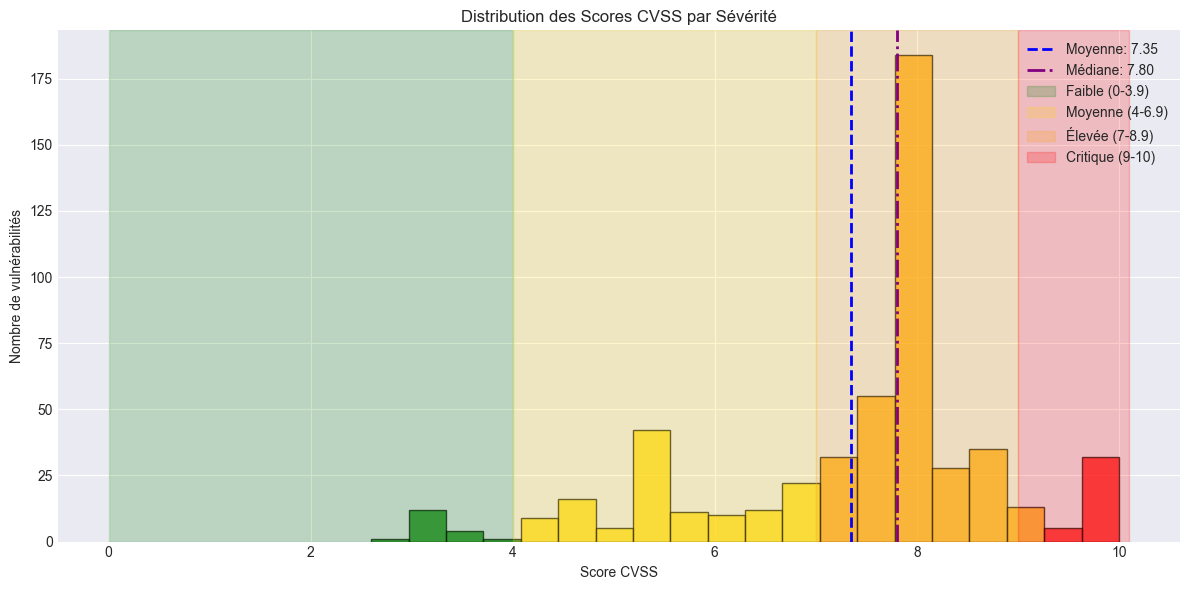

Nombre de valeurs disponibles: 529/1282 (41.3%)
Moyenne: 7.35
Médiane: 7.80
Écart-type: 1.46
Minimum: 2.60
Maximum: 10.00


In [17]:
#TOUJOURS ETAPE 5 - Visualisation -----------------------------------------------

#Histogramme des scores CVSS avec couleurs par sévérité

import matplotlib.pyplot as plt
import numpy as np


cvss_clean = df[df['CVSS Score'].notna()]['CVSS Score']                         #Pour garder que les valeurs non null


def get_color(score):
    if score < 4.0:
        return 'green'
    elif score < 7.0:
        return 'gold'
    elif score < 9.0:
        return 'orange'
    else:
        return 'red'

#Historigramme = .hist
fig, ax = plt.subplots(figsize=(12, 6))                                         #fig = l'onglet, axe = la où ce sera dessiné, figsize = 12 pouces x 6 pouces

n, bins, patches = ax.hist(cvss_clean, bins=20, edgecolor='black', alpha=0.7)   # n = nb vulnérabilités pour chaque interval, bins = les barres sur l'axe X, patches = couleurs
                                                                                #Ici on prend les données = cvss_clean, 20 intervalles (bars) = bins, - , alpha = transparence



for patch, left_edge in zip(patches, bins[:-1]):                                #zip = créer une liste de tuples avec [(patches[0], bins[0]), ([1], [1]), ...]
    if left_edge < 4.0:
        patch.set_facecolor('green')                                            #Si la barre commence avant 4
    elif left_edge < 7.0:
        patch.set_facecolor('gold')                                             #" entre 4 et 7
    elif left_edge < 9.0:
        patch.set_facecolor('orange')                                           #" entre 7 et 9
    else:
        patch.set_facecolor('red')                                              #au delà



#Lignes verticales pour la moyenne et la médiane avec axvline : Axe X + Vertical + line (ligne verticale sur l'axe X)
ax.axvline(x=cvss_clean.mean(), color='blue', linestyle='--', linewidth=2, label=f'Moyenne: {cvss_clean.mean():.2f}')
ax.axvline(x=cvss_clean.median(), color='purple', linestyle='-.', linewidth=2, label=f'Médiane: {cvss_clean.median():.2f}')

#axvspan = Axe X - Vertical SPAN (étendue verticale)
ax.axvspan(0, 4, alpha=0.2, color='green', label='Faible (0-3.9)')
ax.axvspan(4, 7, alpha=0.2, color='gold', label='Moyenne (4-6.9)')
ax.axvspan(7, 9, alpha=0.2, color='orange', label='Élevée (7-8.9)')
ax.axvspan(9, 10.1, alpha=0.2, color='red', label='Critique (9-10)')


ax.set_xlabel('Score CVSS')
ax.set_ylabel('Nombre de vulnérabilités')
ax.set_title('Distribution des Scores CVSS par Sévérité')
ax.legend(loc='upper right')


plt.tight_layout()
plt.show()

print(f"Nombre de valeurs disponibles: {len(cvss_clean)}/{len(df)} ({len(cvss_clean)/len(df)*100:.1f}%)")
print(f"Moyenne: {cvss_clean.mean():.2f}")
print(f"Médiane: {cvss_clean.median():.2f}")
print(f"Écart-type: {cvss_clean.std():.2f}")
print(f"Minimum: {cvss_clean.min():.2f}")
print(f"Maximum: {cvss_clean.max():.2f}")